## Data 201 - Homework #4 - Logistic Regression

### Robert Gravatt

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Part A: Statsmodels for Inference
import statsmodels.formula.api as smf

# Part C: Scikit-learn for Prediction
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

# Load the data
try:
    df = pd.read_csv('housing.csv')
    print("Success: 'housing.csv' loaded correctly!")
    print(df.shape)
except FileNotFoundError:
    print("Error: 'housing.csv' was not found.")

Success: 'housing.csv' loaded correctly!
(600, 6)


### Create Binary Outcome

In [9]:
# Calculate the median price
median_price = df['price'].median()

# Create the binary target variable (1 for expensive, 0 for less expensive)
# astype(int) converts True/False to 1/0
df['high_price'] = (df['price'] > median_price).astype(int)

### Exploratory Data Analysis (EDA)

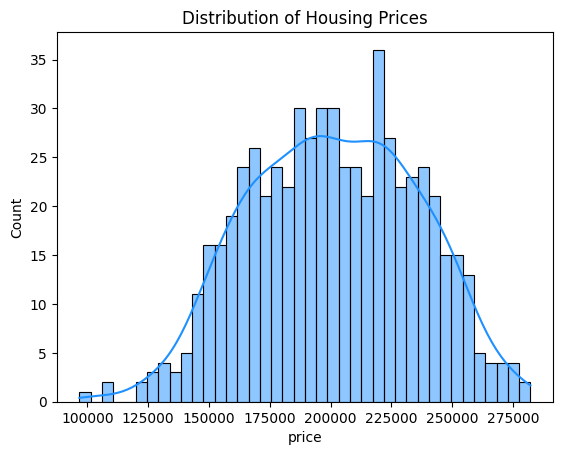

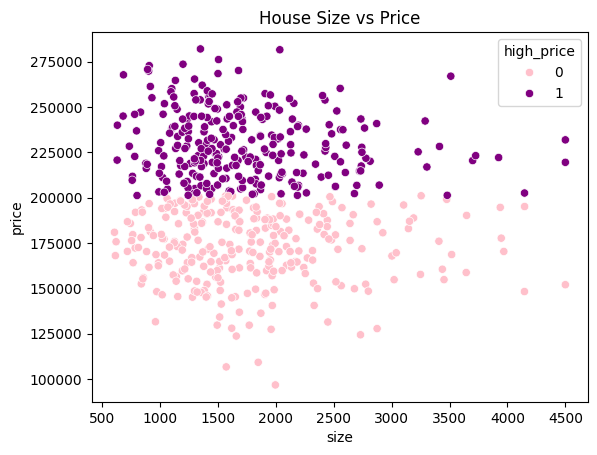

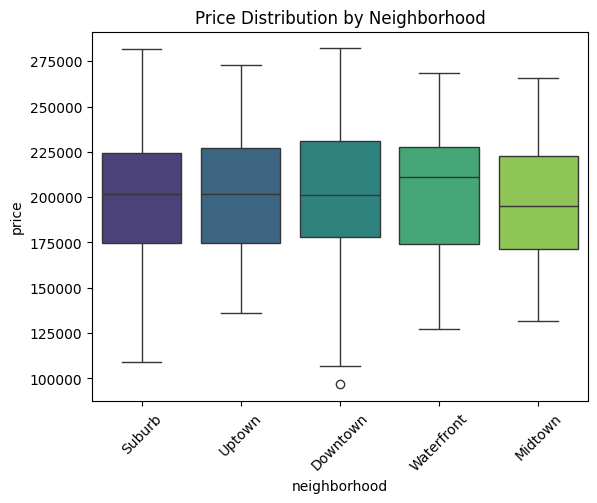

In [25]:
# 1. Histogram of price
sns.histplot(df['price'], bins=40, kde=True, color="dodgerblue")
plt.title('Distribution of Housing Prices')
plt.show()

# 2. Scatter plot: size vs price
sns.scatterplot(data=df, x='size', y='price', hue='high_price', palette=["pink", "purple"])
plt.title('House Size vs Price')
plt.show()

# 3. Boxplot: price by neighborhood
sns.boxplot(data=df, x='neighborhood', y='price', hue='neighborhood', palette='viridis', legend=False)
plt.title('Price Distribution by Neighborhood')
plt.xticks(rotation=45) # Useful if neighborhood names are long
plt.show()

### Part A: Logistic Regression for Inference
Now that we have explored the dataset and established our binary target variable (high_price), our next step is to fit a logistic regression model.

In this section, our primary goal is inference—we want to understand the underlying relationships between our features and the target. Specifically, we want to see how a house's size, number of bedrooms, and neighborhood influence the odds of it being categorized as "expensive."

To achieve this in Python, we will use the statsmodels library. In transitioning from R, statsmodels is the Python equivalent of using the glm() function. It allows us to:

Use familiar R-style formulas (e.g., y ~ x1 + x2).

Automatically handle categorical variables using the C() wrapper.

Generate a comprehensive statistical summary that includes coefficients, standard errors, and p-values to check for statistical significance.


In [22]:
# 1. Fit the logistic regression model

# C() tells statsmodels to treat 'neighborhood' as a Categorical variable (like factor() in R)
model = smf.logit("high_price ~ size + bedrooms + C(neighborhood)", data=df).fit()

# Print the standard, detailed summary (similar to summary(model) in R)
print(model.summary())

print("\n" + "="*50 + "\n") # Just a visual divider

# 2. Create the required custom table

# We extract the parameters, p-values, and calculate the Odds Ratios
results_table = pd.DataFrame({
    'Coefficient': model.params,
    'P-Value': round(model.pvalues, 4), # Rounding
    'Odds Ratio': np.exp(model.params)  # Exp(coef) gives the odds ratio
})

# Display
display(results_table)

Optimization terminated successfully.
         Current function value: 0.684990
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:             high_price   No. Observations:                  524
Model:                          Logit   Df Residuals:                      517
Method:                           MLE   Df Model:                            6
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                 0.01177
Time:                        18:07:16   Log-Likelihood:                -358.93
converged:                       True   LL-Null:                       -363.21
Covariance Type:            nonrobust   LLR p-value:                    0.2006
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.3796      0.289      1.311      0.

,Coefficient,P-Value,Odds Ratio
Intercept,0.379564,0.1897,1.461647
C(neighborhood)[T.Midtown],-0.306505,0.2784,0.736015
C(neighborhood)[T.Suburb],0.107086,0.6752,1.113030
C(neighborhood)[T.Uptown],0.047048,0.8648,1.048173
C(neighborhood)[T.Waterfront],0.413047,0.2431,1.511416
size,-0.000521,0.0367,0.999479
bedrooms,0.232249,0.0822,1.261433


### Part A: Short Analysis
1. Which predictors appear statistically significant?

Answer: Using the standard threshold of 0.05, only size is statistically significant, as its p-value is 0.0367 (which is < 0.05).

Note: bedrooms has a p-value of 0.0822. None of the neighborhoods are statistically significant.

2. Which neighborhood has higher odds of expensive homes?

Answer: Waterfront.

Why: Looking at the Odds Ratio column for the categorical neighborhood variables, C(neighborhood)[T.Waterfront] has the highest value at 1.511416. This means homes in the Waterfront neighborhood have the highest odds of being in the "expensive" category compared to the Downtown baseline neighborhood (which is alphabetically first).

### Part B: Interpretation
Interpreting the 'Bedrooms' Variable:
Looking at the variable for bedrooms, the calculated odds ratio is 1.26.

In plain language, this means that for every additional bedroom a house has, the odds of that house being classified as "expensive" increase by a factor of 1.26 (which is roughly a 26% increase in odds). This assumes that all other factors—like the total size of the house and the neighborhood it is located in—remain exactly the same.

### Part C: Prediction Workflow (scikit-learn)
In this section, we shift our focus from statistical inference to prediction. Our goal is to build a machine learning model that can accurately classify whether a new, unseen house will be expensive or not based on its features.

To do this, we will use scikit-learn. The workflow involves:

1. Encoding Categorical Variables: Converting text features (neighborhood and type) into binary dummy variables.

2. Train/Test Split: Holding out 20% of our data to evaluate how well the model generalizes to new data.

3. Model Fitting: Training the logistic regression model on the remaining 80%.

4. Evaluation: Scoring the model using Accuracy and the ROC-AUC metric.

Model Accuracy: 0.4667
Model ROC-AUC:  0.4394
------------------------------


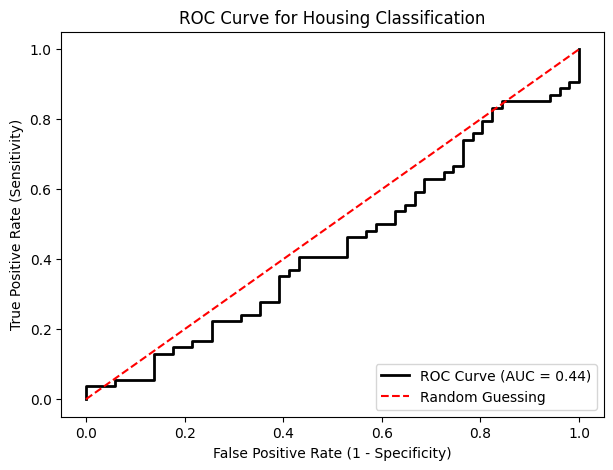

In [30]:
# 1. Prepare Features (X) and Target (y)
# Using .dropna() here to remove any rows with missing values
df_clean = df[['size', 'bedrooms', 'neighborhood', 'type', 'high_price']].dropna()

X = pd.get_dummies(df_clean[['size', 'bedrooms', 'neighborhood', 'type']], drop_first=True)
y = df_clean['high_price']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Fit Logistic Regression
model_predictive = LogisticRegression(max_iter=1000)
model_predictive.fit(X_train, y_train)

# 4. Predict on the test set
y_pred = model_predictive.predict(X_test)
y_probs = model_predictive.predict_proba(X_test)[:, 1]

# 5. Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs)

print("Model Accuracy: {:.4f}".format(accuracy))
print("Model ROC-AUC:  {:.4f}".format(roc_auc))
print("-" * 30)

# Plot the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='black', linewidth=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve for Housing Classification')
plt.legend(loc='lower right')
plt.show()

### Part D: Model Understanding
#### Accuracy vs AUC

Accuracy measures the percentage of correct predictions at a single fixed threshold, usually 0.5. However, ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) is often preferred because it evaluates the model's performance across all possible thresholds. While accuracy can be misleading if the classes are imbalanced, AUC provides a single value representing the probability that the model will rank a randomly chosen positive instance higher than a negative one.
#### The Math of AUC
The AUC is essentially a calculation of the area under the ROC plot. This is typically achieved using the trapezoidal rule to integrate the area beneath the segments connecting the various threshold points. A perfect model has an AUC of 1.0, while a model that guesses randomly has an AUC of 0.5.
#### Inference vs Prediction
For policy analysis, I would choose the statistical inference approach using statsmodels. This method provides p-values and interpretable coefficients that help explain the relationship between variables, which is essential for understanding why certain factors lead to higher prices.

For prediction tasks, I would choose the scikit-learn workflow. This approach focuses on the model's ability to generalize to new data and provides specialized tools for measuring predictive performance, making it better suited for practical applications like estimating the value of a new listing.

### Part E: Interesting Pattern

#### The Median Threshold
An interesting pattern in the scatter plot above is the perfect horizontal separation between high and low-priced homes at the $200,000 mark. This confirms that our target variable was created using a median split. Interestingly, while size is a strong predictor, there is a "transition zone" between 2,000 and 3,000 square feet where houses of the same size can fall into either category. This suggests that in this middle-size range, other factors like neighborhood or number of bedrooms become the deciding factor in whether a home crosses the "high price" threshold.